# EMG Data Analysis

Processes Open Ephys recordings: loads session → bandpass filters → rectifies → computes envelope → detects muscle onset (ON threshold).

**Sections:**
1. Imports
2. Helper Functions
3. Configuration
4. Load Session & Recording
5. EMG Signal Processing
6. Plot 1: Full Trace — Filtered EMG
7. Plot 2: Segmented Viewer — Filtered EMG (interactive buttons)
8. Plot 3: Rectified EMG (full + segmented)
9. Plot 4: EMG Envelope & Onset Threshold

## 1. Imports

> **Note:** `%matplotlib widget` requires `ipympl` (`pip install ipympl`).  
> Use `%matplotlib notebook` for classic Jupyter Notebook if needed.

In [2]:
# %matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
import numpy as np
from open_ephys.analysis import Session
import os
import re
from scipy.signal import butter, filtfilt, lfilter
from collections import defaultdict
import scipy.stats as stats
from IPython.display import display

## 2. Helper Functions

In [3]:
def scan_experiment_structure(session_dir, record_node_name="Record Node 111"):
    node_path = os.path.join(session_dir, record_node_name)
    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [
                r for r in sorted(os.listdir(exp_path))
                if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")
            ]
            experiment_info[item] = recordings
    return experiment_info

## 3. Configuration

Set `w` and `directory` before running any other cells.

| `w` value | Record Node |
|-----------|-------------|
| `0`       | Record Node 106 |
| `1`       | Record Node 111 |

In [5]:
# ==== Select record node ====
# w = 0 → Record Node 106
# w = 1 → Record Node 111
w = 0

directory = 'MINT-03/JawEMG_MINT_03_10Plt_31720262026-03-17_11-47-33_003'

recording_index = 0  # which recording to load

## 4. Load Session & Recording

In [6]:
print("directory =", directory)
print("exists?", os.path.exists(directory))
print("is folder?", os.path.isdir(directory))
print("contents:", os.listdir(directory))

session = Session(directory)
print("\nSession loaded successfully.")
print(session)

directory = MINT-03/JawEMG_MINT_03_10Plt_31720262026-03-17_11-47-33_003
exists? True
is folder? True
contents: ['Record Node 106', 'Record Node 111']

Session loaded successfully.

Open Ephys Recording Session Object
Directory: MINT-03/JawEMG_MINT_03_10Plt_31720262026-03-17_11-47-33_003

<object>.recordnodes:
  Index 0: Record Node 106 (binary format)
  Index 1: Record Node 111 (binary format)



In [7]:
record_node_name = "Record Node 106" if w == 0 else "Record Node 111"

structure = scan_experiment_structure(directory, record_node_name)
print("Experiment structure:", structure)

try:
    recording = session.recordnodes[w].recordings[recording_index]
    print("Loaded:", recording)
except IndexError:
    print(f"Recording index {recording_index} not found.")

# Parse path components
directory_str = recording.directory
parts = directory_str.split(os.sep)
record_node_name = parts[-3]
experiment_name  = parts[-2]
recording_name   = parts[-1]

print(f"\nRecord node : {record_node_name}")
print(f"Experiment  : {experiment_name}")
print(f"Recording   : {recording_name}")

Experiment structure: defaultdict(<class 'list'>, {'experiment1': ['recording1']})
Loaded: Open Ephys GUI Recording
ID: 0x20e3883af90
Format: Binary
Directory: MINT-03/JawEMG_MINT_03_10Plt_31720262026-03-17_11-47-33_003\Record Node 106\experiment1\recording1
Experiment Index: 0
Recording Index: 0

Record node : Record Node 106
Experiment  : experiment1
Recording   : recording1


In [8]:
continuous_list = recording.continuous
print(f"Number of continuous streams: {len(continuous_list)}")

stream = continuous_list[0]
print(stream)

metadata = stream.metadata
channel_names = metadata.channel_names
sample_rate   = metadata.sample_rate
num_channels  = metadata.num_channels

print("Sample rate :", sample_rate)
print("Num channels:", num_channels)
print("Channel names:", channel_names)

Number of continuous streams: 1
Continuous Data: Acquisition_Board-100.Rhythm Data/ (format='binary', mmap_mode=r)
├─── Samples: 861319 samples x 4 channels
└─── ContinuousMetadata(source_node_id=100,
                   source_node_name='Acquisition Board',
                   stream_name='Rhythm Data',
                   sample_rate=2000.0,
                   num_channels=4,
                   channel_names=['CH1', 'CH5', 'CH7', 'CH11'],
                   bit_volts=[0.1949999928474426,
                              0.1949999928474426,
                              0.1949999928474426,
                              0.1949999928474426])

Sample rate : 2000.0
Num channels: 4
Channel names: ['CH1', 'CH5', 'CH7', 'CH11']


## 5. EMG Signal Processing

Load raw samples, apply bandpass filter (100–999 Hz), and compute rectified signal.

In [9]:
# Load continuous data
timestamps = recording.continuous[0].timestamps
n_timestamps = timestamps.shape[0]
data = recording.continuous[0].get_samples(start_sample_index=0, end_sample_index=n_timestamps)
print("Data shape:", data.shape)

# Raw differential
emg1_raw = data[:, 2]
emg2_raw = data[:, 3]
differential = emg2_raw - emg1_raw

# Bandpass filter (used if signal is NOT already online-filtered)
lowcut  = 100
highcut = 999.99
b, a = butter(2, np.array([lowcut, highcut]) / (sample_rate / 2), btype='bandpass')
# differential_filt = filtfilt(b, a, differential)  # uncomment for offline (raw) data

# Use online-filtered channel directly (comment out if data is NOT online-filtered)
differential_filt = data[:, 3]

# Rectification
differential_rect = np.abs(differential_filt)

print("Processing complete.")

Data shape: (861319, 4)
Processing complete.


## 6. Plot 1: Full Trace — Filtered EMG

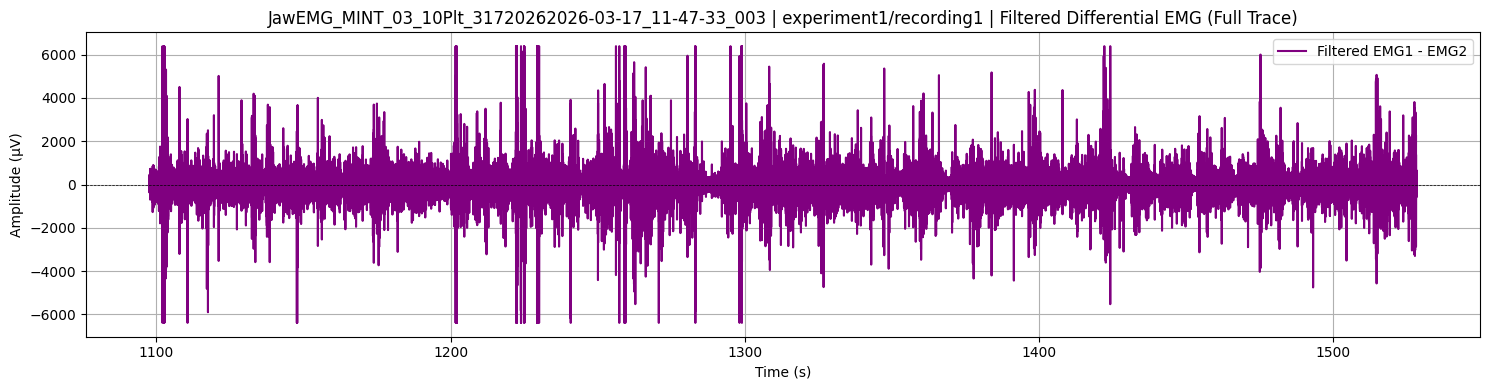

In [10]:
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_filt, label="Filtered EMG1 - EMG2", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{os.path.basename(directory)} | {experiment_name}/{recording_name} | Filtered Differential EMG (Full Trace)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (\u03bcV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Plot 2: Segmented Viewer — Filtered EMG

### 7a. `plot_segment` Helper

Static function for plotting a single segment (no interactive buttons).

In [11]:
segment_duration = 50  # seconds per segment for static viewer
total_time   = timestamps[-1] - timestamps[0]
num_segments = int(np.ceil(total_time / segment_duration))

def plot_segment(segment_idx):
    start_time = timestamps[0] + segment_idx * segment_duration
    end_time   = min(start_time + segment_duration, timestamps[-1])
    mask = (timestamps >= start_time) & (timestamps < end_time)
    plt.figure(figsize=(15, 4))
    plt.plot(timestamps[mask] - start_time, differential_filt[mask],
             label="Filtered EMG1 - EMG2", color='purple')
    plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
    plt.title(
        f"{os.path.basename(directory)} | {experiment_name}/{recording_name} "
        f"| Segment {segment_idx+1}/{num_segments} | {start_time:.1f}\u2013{end_time:.1f}s"
    )
    plt.xlabel("Time within segment (s)")
    plt.ylabel("Amplitude (\u03bcV)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Example: plot_segment(0)  # call with desired segment index

### 7b. Interactive Segmented Viewer (Prev/Next Buttons)

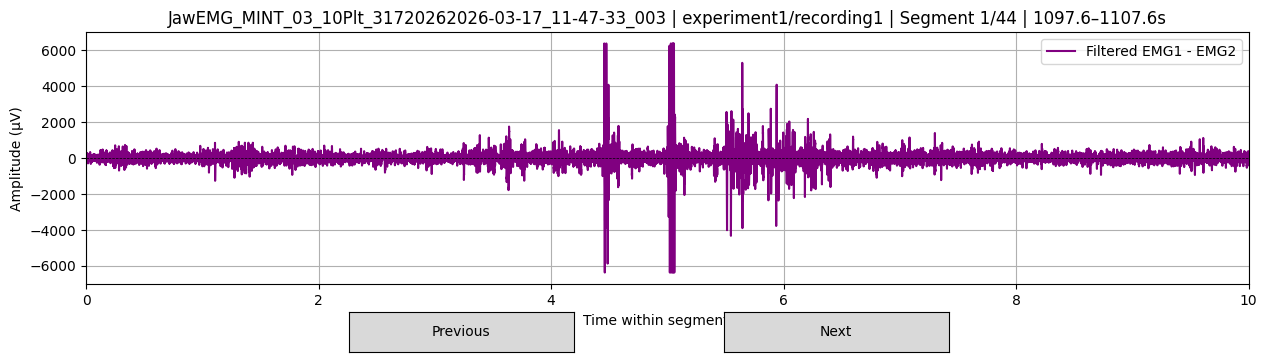

In [13]:
segment_duration = 10  # seconds per segment
t0    = float(timestamps[0])
t_end = float(timestamps[-1])
total_time   = t_end - t0
num_segments = int(np.ceil(total_time / segment_duration))

state = {"idx": 0}

fig, ax = plt.subplots(figsize=(15, 4))
plt.subplots_adjust(bottom=0.25)

line, = ax.plot([], [], color='purple', label="Filtered EMG1 - EMG2")
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.set_xlabel("Time within segment (s)")
ax.set_ylabel("Amplitude (\u03bcV)")
ax.grid(True)
ax.legend()
title = ax.set_title("")

def update_plot():
    i = state["idx"]
    start_time = t0 + i * segment_duration
    end_time   = min(start_time + segment_duration, t_end)
    mask = (timestamps >= start_time) & (timestamps < end_time)
    x = timestamps[mask] - start_time
    y = differential_filt[mask]
    line.set_data(x, y)
    ax.set_xlim(0, end_time - start_time)
    if y.size > 0:
        ypad = 0.05 * (np.max(y) - np.min(y) + 1e-9)
        ax.set_ylim(np.min(y) - ypad, np.max(y) + ypad)
    title.set_text(
        f"{os.path.basename(directory)} | {experiment_name}/{recording_name} "
        f"| Segment {i+1}/{num_segments} | {start_time:.1f}\u2013{end_time:.1f}s"
    )
    fig.canvas.draw_idle()

def next_segment(event):
    if state["idx"] < num_segments - 1:
        state["idx"] += 1
        update_plot()

def prev_segment(event):
    if state["idx"] > 0:
        state["idx"] -= 1
        update_plot()

axprev = plt.axes([0.30, 0.08, 0.15, 0.10])
axnext = plt.axes([0.55, 0.08, 0.15, 0.10])
bprev = Button(axprev, "Previous")
bnext = Button(axnext, "Next")
bprev.on_clicked(prev_segment)
bnext.on_clicked(next_segment)

update_plot()
plt.show()

## 8. Plot 3: Rectified EMG

### 8a. Full Trace

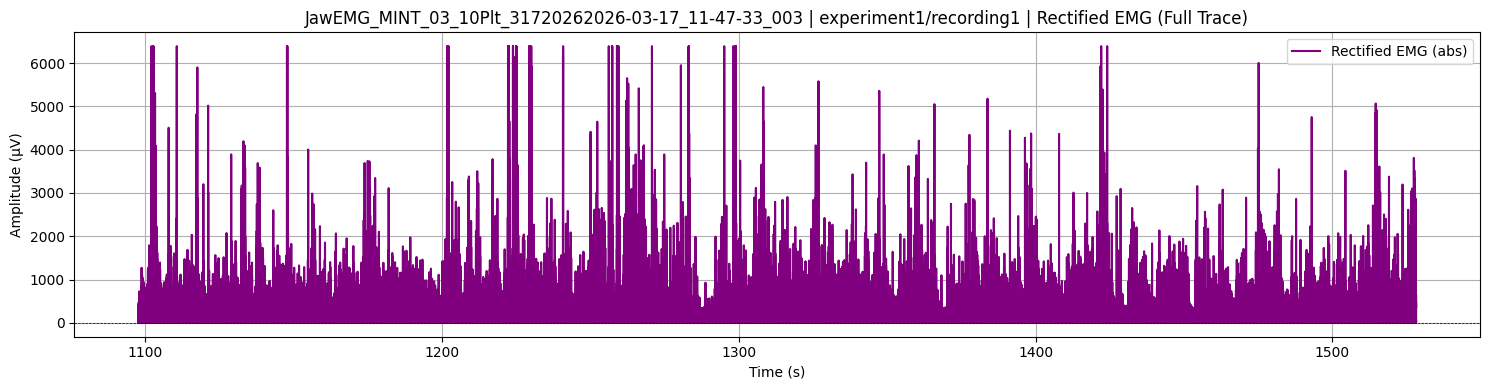

In [14]:
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_rect, label="Rectified EMG (abs)", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{os.path.basename(directory)} | {experiment_name}/{recording_name} | Rectified EMG (Full Trace)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (\u03bcV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 8b. Rectified Segmented Viewer (Prev/Next Buttons)

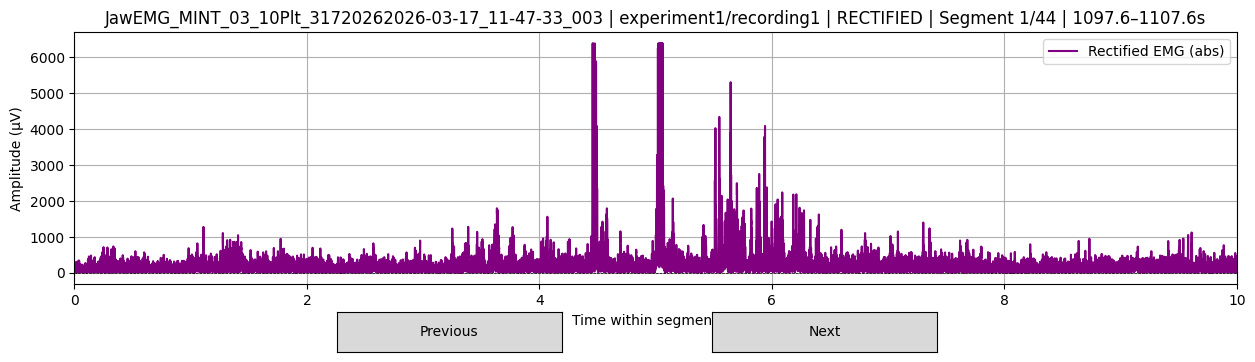

In [15]:
segment_duration_rect = 10  # seconds
t0    = float(timestamps[0])
t_end = float(timestamps[-1])
total_time        = t_end - t0
num_segments_rect = int(np.ceil(total_time / segment_duration_rect))

state_rect = {"idx": 0}

fig_rect, ax_rect = plt.subplots(figsize=(15, 4))
plt.subplots_adjust(bottom=0.25)

line_rect, = ax_rect.plot([], [], color='purple', label="Rectified EMG (abs)")
ax_rect.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax_rect.set_xlabel("Time within segment (s)")
ax_rect.set_ylabel("Amplitude (\u03bcV)")
ax_rect.grid(True)
ax_rect.legend()
title_rect = ax_rect.set_title("")

def update_plot_rect():
    i = state_rect["idx"]
    start_time = t0 + i * segment_duration_rect
    end_time   = min(start_time + segment_duration_rect, t_end)
    mask = (timestamps >= start_time) & (timestamps < end_time)
    x = timestamps[mask] - start_time
    y = differential_rect[mask]
    line_rect.set_data(x, y)
    ax_rect.set_xlim(0, end_time - start_time)
    if y.size > 0:
        ypad = 0.05 * (np.max(y) - np.min(y) + 1e-9)
        ax_rect.set_ylim(np.min(y) - ypad, np.max(y) + ypad)
    title_rect.set_text(
        f"{os.path.basename(directory)} | {experiment_name}/{recording_name} "
        f"| RECTIFIED | Segment {i+1}/{num_segments_rect} | {start_time:.1f}\u2013{end_time:.1f}s"
    )
    fig_rect.canvas.draw_idle()

def next_segment_rect(event):
    if state_rect["idx"] < num_segments_rect - 1:
        state_rect["idx"] += 1
        update_plot_rect()

def prev_segment_rect(event):
    if state_rect["idx"] > 0:
        state_rect["idx"] -= 1
        update_plot_rect()

axprev_rect = plt.axes([0.30, 0.08, 0.15, 0.10])
axnext_rect = plt.axes([0.55, 0.08, 0.15, 0.10])
bprev_rect = Button(axprev_rect, "Previous")
bnext_rect = Button(axnext_rect, "Next")
bprev_rect.on_clicked(prev_segment_rect)
bnext_rect.on_clicked(next_segment_rect)

update_plot_rect()
plt.show()

## 9. Plot 4: EMG Envelope & Onset Threshold

### 9a. Compute Envelope & Threshold Parameters

Low-pass filter the rectified signal to get the envelope, then find the ON threshold using the quietest 5-second baseline window.

In [16]:
# ---- Envelope (low-pass of rectified signal) ----
envelope_lowpass_hz = 2  # Hz — adjust as needed (e.g. 3, 10, 40)
wn_env = envelope_lowpass_hz / (sample_rate / 2)
b_env, a_env = butter(4, wn_env, btype='lowpass')
differential_env = filtfilt(b_env, a_env, differential_rect)

# ---- Robust baseline: find quietest 5-second window anywhere in recording ----
win_s  = 5.0  # seconds
win_n  = int(win_s * sample_rate)
step_s = 0.1  # step size (seconds)
step_n = int(step_s * sample_rate)

env = differential_env
mov_std = np.array([
    np.std(env[i:i + win_n])
    for i in range(0, len(env) - win_n, step_n)
])

best_idx = int(np.argmin(mov_std))
start_i  = best_idx * step_n
end_i    = start_i + win_n
base_vals = env[start_i:end_i]

baseline_mean = np.mean(base_vals)
baseline_sd   = np.std(base_vals, ddof=1)
ON_thr = baseline_mean + 6 * baseline_sd

print(f"Quiet window baseline mean = {baseline_mean:.2f} \u00b5V")
print(f"Quiet window baseline SD   = {baseline_sd:.2f} \u00b5V")
print(f"ON threshold               = {ON_thr:.2f} \u00b5V")

Quiet window baseline mean = 101.90 µV
Quiet window baseline SD   = 7.46 µV
ON threshold               = 146.65 µV


### 9b. Baseline Window Visualization

Shows where the auto-selected quiet baseline window falls on the full envelope trace.

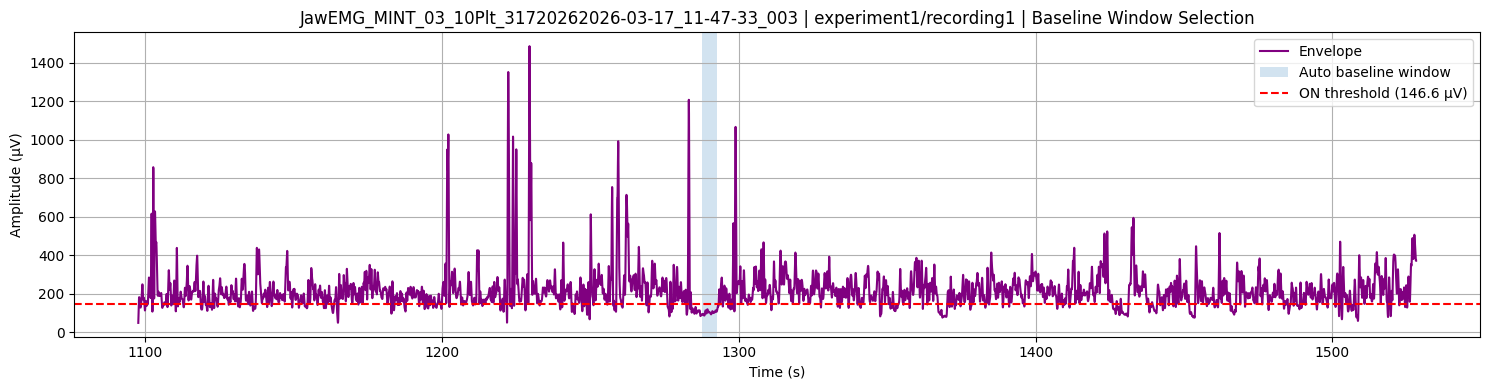

In [17]:
plt.figure(figsize=(15, 4))
plt.plot(timestamps, env, color='purple', label="Envelope")
plt.axvspan(timestamps[start_i], timestamps[end_i], alpha=0.2, label="Auto baseline window")
plt.axhline(ON_thr, color='red', linestyle='--', label=f"ON threshold ({ON_thr:.1f} \u00b5V)")
plt.title(f"{os.path.basename(directory)} | {experiment_name}/{recording_name} | Baseline Window Selection")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (\u00b5V)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 9c. Envelope Full Trace

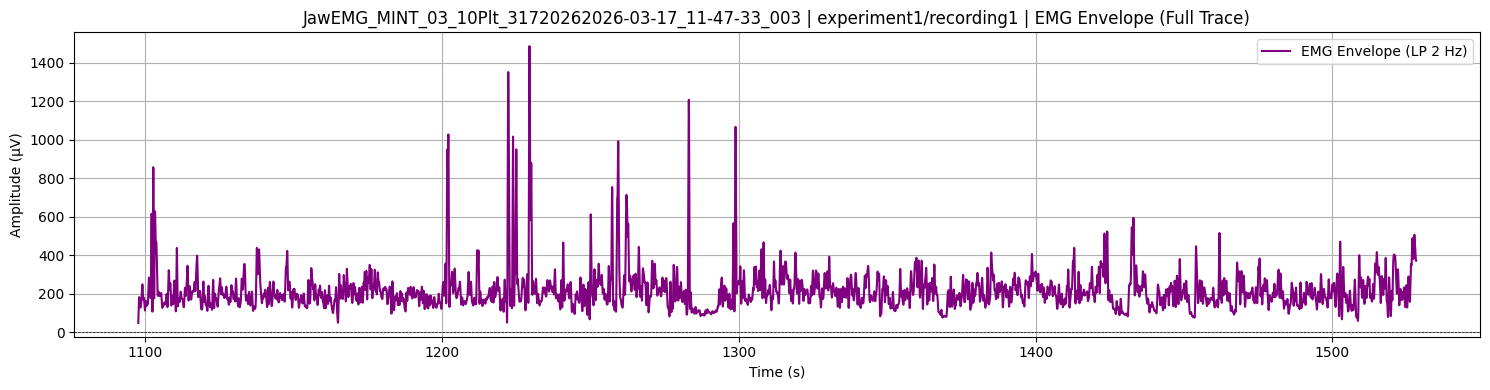

In [18]:
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_env,
         label=f"EMG Envelope (LP {envelope_lowpass_hz} Hz)", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{os.path.basename(directory)} | {experiment_name}/{recording_name} | EMG Envelope (Full Trace)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (\u03bcV)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 9d. Threshold Check Plot

Envelope overlaid with the ON threshold line and file metadata box.

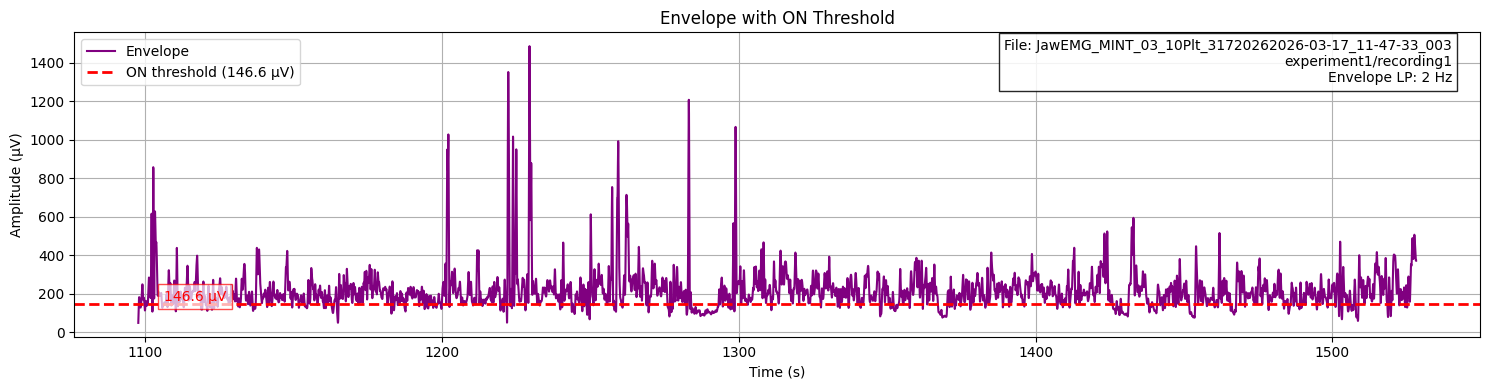

In [19]:
fig_thr, ax_thr = plt.subplots(figsize=(15, 4))

ax_thr.plot(timestamps, differential_env, color='purple', label="Envelope")
ax_thr.axhline(ON_thr, color='red', linestyle='--', linewidth=2,
               label=f"ON threshold ({ON_thr:.1f} \u00b5V)")

# ON threshold value label
x_text = timestamps[0] + 0.02 * (timestamps[-1] - timestamps[0])
ax_thr.text(x_text, ON_thr, f"{ON_thr:.1f} \u00b5V",
            color='red', fontsize=10, va='bottom', ha='left',
            bbox=dict(facecolor='white', edgecolor='red', alpha=0.7))

# File info box (top-right)
file_info_text = (
    f"File: {os.path.basename(directory)}\n"
    f"{experiment_name}/{recording_name}\n"
    f"Envelope LP: {envelope_lowpass_hz} Hz"
)
ax_thr.text(0.98, 0.98, file_info_text,
            transform=ax_thr.transAxes,
            fontsize=10, va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.85))

ax_thr.set_title("Envelope with ON Threshold")
ax_thr.set_xlabel("Time (s)")
ax_thr.set_ylabel("Amplitude (\u00b5V)")
ax_thr.grid(True)
ax_thr.legend()
plt.tight_layout()
plt.show()

### 9e. Envelope Segmented Viewer (Prev/Next Buttons)

Shows ON threshold line and auto-scaling y-axis per segment.

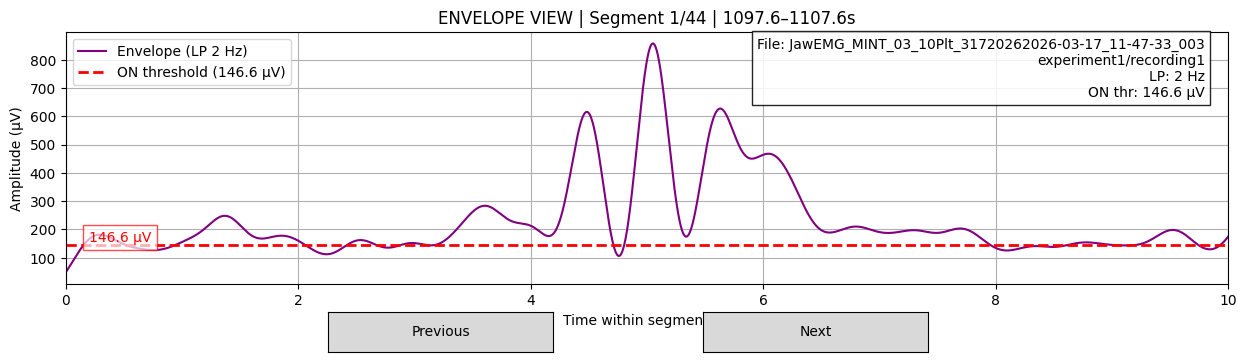

In [20]:
segment_duration_env = 10  # seconds
t0_env    = float(timestamps[0])
t_end_env = float(timestamps[-1])
total_time_env   = t_end_env - t0_env
num_segments_env = int(np.ceil(total_time_env / segment_duration_env))

state_env = {"idx": 0}

fig_env, ax_env = plt.subplots(figsize=(15, 4))
plt.subplots_adjust(bottom=0.25)

line_env, = ax_env.plot([], [], color='purple',
                        label=f"Envelope (LP {envelope_lowpass_hz} Hz)")
on_line = ax_env.axhline(ON_thr, color='red', linestyle='--', linewidth=2,
                         label=f"ON threshold ({ON_thr:.1f} \u00b5V)")
ax_env.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax_env.set_xlabel("Time within segment (s)")
ax_env.set_ylabel("Amplitude (\u03bcV)")
ax_env.grid(True)
ax_env.legend()
title_env = ax_env.set_title("")

on_text = ax_env.text(0, ON_thr, f"{ON_thr:.1f} \u00b5V",
                      color='red', fontsize=10, va='bottom', ha='left',
                      bbox=dict(facecolor='white', edgecolor='red', alpha=0.7))

info_box_env = ax_env.text(
    0.98, 0.98, "",
    transform=ax_env.transAxes,
    fontsize=10, va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.85)
)

def update_plot_env():
    i = state_env["idx"]
    start_time = t0_env + i * segment_duration_env
    end_time   = min(start_time + segment_duration_env, t_end_env)
    mask = (timestamps >= start_time) & (timestamps < end_time)
    x = timestamps[mask] - start_time
    y = differential_env[mask]
    line_env.set_data(x, y)
    ax_env.set_xlim(0, end_time - start_time)
    if y.size > 0:
        ypad = 0.05 * (np.max(y) - np.min(y) + 1e-9)
        ymin = min(np.min(y) - ypad, ON_thr - ypad)
        ymax = max(np.max(y) + ypad, ON_thr + ypad)
        ax_env.set_ylim(ymin, ymax)
    x_text_seg = 0.02 * (end_time - start_time)
    on_text.set_position((x_text_seg, ON_thr))
    title_env.set_text(
        f"ENVELOPE VIEW | Segment {i+1}/{num_segments_env} | {start_time:.1f}\u2013{end_time:.1f}s"
    )
    info_box_env.set_text(
        f"File: {os.path.basename(directory)}\n"
        f"{experiment_name}/{recording_name}\n"
        f"LP: {envelope_lowpass_hz} Hz\n"
        f"ON thr: {ON_thr:.1f} \u00b5V"
    )
    fig_env.canvas.draw_idle()

def next_segment_env(event):
    if state_env["idx"] < num_segments_env - 1:
        state_env["idx"] += 1
        update_plot_env()

def prev_segment_env(event):
    if state_env["idx"] > 0:
        state_env["idx"] -= 1
        update_plot_env()

axprev_env = plt.axes([0.30, 0.08, 0.15, 0.10])
axnext_env = plt.axes([0.55, 0.08, 0.15, 0.10])
bprev_env = Button(axprev_env, "Previous")
bnext_env = Button(axnext_env, "Next")
bprev_env.on_clicked(prev_segment_env)
bnext_env.on_clicked(next_segment_env)

update_plot_env()
plt.show()